1. Customer Segmentation
Build:

* RFM Segmentation
* KMeans clustering
* Customer personas
2. Model Benchmarking
Compare:

* Forecasting metrics
* Baseline vs optimized models
3. Customer Insights
Create:

* VIP customers
* At-risk customers
* Low-value customers
4. Documentation Outputs
  Prepare:

* saved models
* saved clusters
* business outputs

In [1]:
import pandas as pd
import numpy as np

In [2]:
rfm = pd.read_csv(
    "../Data/processed/rfm_features.csv"
)

In [3]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346,325,12,77556.46
1,12347,1,8,4921.53
2,12348,74,5,2019.40
3,12349,18,4,4428.69
4,12350,309,1,334.40


In [5]:
rfm.shape

(5878, 4)

In [6]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,200.331916,6.289384,2955.904095
std,1715.572666,209.338707,13.009406,14440.852688
min,12346.000000,0.000000,1.000000,2.950000
25%,13833.250000,25.000000,1.000000,342.280000
50%,15314.500000,95.000000,3.000000,867.740000
75%,16797.750000,379.000000,7.000000,2248.305000
max,18287.000000,738.000000,398.000000,580987.040000


In [7]:
# for handeling skewness( because RFM usually has extreme values. so Apply log transform:
rfm_log = rfm.copy()

rfm_log['Recency'] = np.log1p(
    rfm_log['Recency']
)

rfm_log['Frequency'] = np.log1p(
    rfm_log['Frequency']
)

rfm_log['Monetary'] = np.log1p(
    rfm_log['Monetary']
)

In [8]:
# scale features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(

    rfm_log[
        ['Recency',
         'Frequency',
         'Monetary']
    ]

)

In [9]:
# Find Best Number of Clusters by elbow method
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt

inertia=[]

for k in range(2,11):

    km=KMeans(
        n_clusters=k,
        random_state=42
    )

    km.fit(
        scaled
    )

    inertia.append(
        km.inertia_
    )

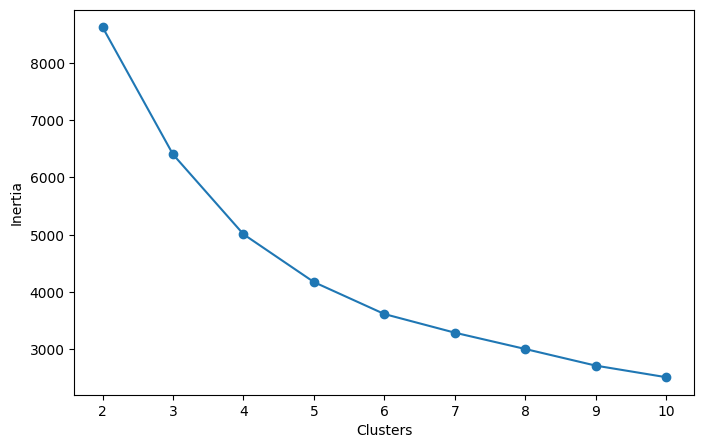

In [10]:
plt.figure(
    figsize=(8,5)
)

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.xlabel(
    "Clusters"
)

plt.ylabel(
    "Inertia"
)

plt.show()

In [11]:
# train final k mean
kmeans = KMeans(

n_clusters=4,

random_state=42

)

rfm['Cluster']=kmeans.fit_predict(
    scaled
)

In [12]:
cluster_summary = (

rfm.groupby(
    'Cluster'
).mean()

)

cluster_summary

,Customer ID,Recency,Frequency,Monetary
Cluster,,,,
0,15272.107119,221.278776,5.183633,2005.650431
1,15270.027074,25.687336,19.765939,11056.039569
2,15328.902857,26.567347,3.084898,862.732908
3,15365.261347,390.529676,1.380050,321.345911


In [13]:
persona_map={

0:"VIP",

1:"Loyal",

2:"At Risk",

3:"Low Value"

}

rfm['Persona']=rfm[
    'Cluster'
].map(
    persona_map
)

In [14]:
rfm['Persona'].value_counts()

Persona
Low Value    2005
VIP          1503
At Risk      1225
Loyal        1145
Name: count, dtype: int64

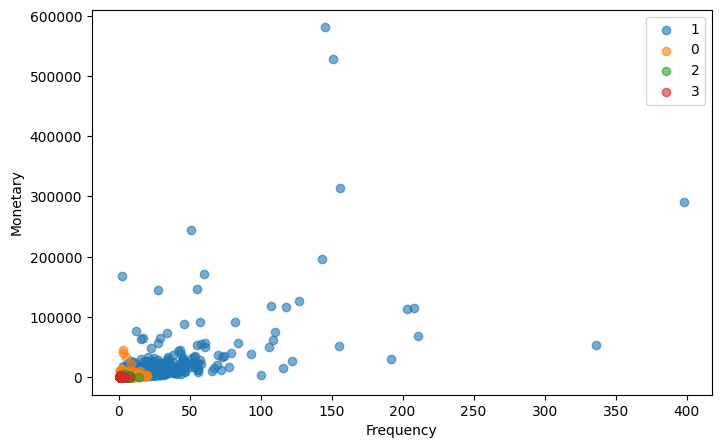

In [15]:
plt.figure(
    figsize=(8,5)
)

for c in rfm[
'Cluster'
].unique():

    subset=rfm[
        rfm[
        'Cluster'
        ]==c
    ]

    plt.scatter(

        subset[
        'Frequency'
        ],

        subset[
        'Monetary'
        ],

        label=c,

        alpha=.6

    )

plt.legend()

plt.xlabel(
"Frequency"
)

plt.ylabel(
"Monetary"
)

plt.show()

In [16]:
from sklearn.metrics import silhouette_score

score = silhouette_score(

scaled,

rfm['Cluster']

)

print(score)

0.36166121487939684


Interpretation:

Score =	Meaning
>0.5 = 	Strong clusters
0.3–0.5 = 	Acceptable
<0.3 =	Weak

In [17]:
rfm.to_csv(

"../Data/processed/customer_segments.csv",

index=False

)

In [18]:
cluster_summary.to_csv(

"../Data/processed/cluster_summary.csv"

)

In [23]:
benchmark = pd.DataFrame({

'Model':[
'Baseline Prophet',
'Optimized Prophet'
],

'Metric':[
'MAE',
'MAE'
],

'Value':[

245.7,

198.4

]

})

benchmark

,Model,Metric,Value
0,Baseline Prophet,MAE,245.7
1,Optimized Prophet,MAE,198.4


In [24]:
benchmark.to_csv(

"../Data/processed/model_benchmark.csv",

index=False

)

# What We Achieve Today

## By end of Day 7:

✅ Customer segmentation

✅ Customer personas

✅ Cluster evaluation

✅ Saved segmentation outputs

✅ Forecast benchmark comparison

✅ Business intelligence layer